This notebook runs the Exhaustive Grid Search for Cat/Dog Binary Classification

Pipeline flow:

```text
Sweet Spot cleaning config
→ image filtering
→ train/validation/test split
→ preprocessing search
→ frozen CNN feature extraction search
→ classical classifier search
→ select best validation config
→ evaluate selected config on held-out test set
```

## Completed exhaustive run summary

The completed run tested all **132 experiments** successfully:

```text
4 preprocessing modes × 1 image size × 3 backbones × 11 classifier variants = 132 experiments
```

Best validation configuration:

| Component | Selected value |
|---|---|
| Preprocessing | `augmented`, image size `224` |
| Feature extraction | `efficientnet_b0`, pretrained ImageNet |
| Classifier | `voting_soft` |
| Validation macro F1 | `0.997009` |
| Validation wrong predictions | `3 / 1003` |
| Test macro F1 | `0.993021` |
| Test wrong predictions | `7 / 1003` |

In [ ]:
from pathlib import Path
import os
import sys
import shutil

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

GITHUB_REPO_URL = "https://github.com/kahn-29/252-MachineLearning-Assignment1.git"
GITHUB_BRANCH = "main"

PROJECT_ROOT = Path("/content")
REPO_DIR = PROJECT_ROOT / "project_repo"

if "YOUR_USERNAME" in GITHUB_REPO_URL or "YOUR_REPOSITORY" in GITHUB_REPO_URL:
    raise ValueError("Please set GITHUB_REPO_URL to your real GitHub repository URL first.")

!pip install -q kagglehub imagehash opencv-python-headless

if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

!git clone --depth 1 --branch "{GITHUB_BRANCH}" "{GITHUB_REPO_URL}" "{REPO_DIR}"

MODULES_DIR = REPO_DIR / "modules"
if not MODULES_DIR.exists():
    raise FileNotFoundError(f"Cannot find modules folder at: {MODULES_DIR}")

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

print("Repository:", REPO_DIR)
print("Using modules directly from:", MODULES_DIR)
for path in sorted(MODULES_DIR.glob("*.py")):
    print("-", path.name)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.0 MB/s eta 0:00:00
Cloning into '/content/project_repo'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 27 (delta 0), reused 18 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 4.89 MiB | 9.93 MiB/s, done.
Repository: /content/project_repo
Using modules directly from: /content/project_repo/modules
- __init__.py
- artifacts.py
- backbones.py
- classical_models.py
- cleaning.py
- config_utils.py
- data_utils.py
- datasets.py
- deep_learning.py
- evaluation.py
- feature_extraction.py
- grid_search.py
- image_audit.py
- threshold_experiments.py
- transforms.py
- visualization.py


## 1. Import libraries and project modules

In [ ]:
from pathlib import Path
import copy
import json
import re
import time
import gc
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from modules.config_utils import (
    get_default_config,
    deep_update,
    validate_config,
    set_seed,
    get_device,
    ensure_dirs,
)

from modules.data_utils import (
    resolve_dataset_root,
    build_raw_dataframe,
    stratified_split,
    summarize_class_distribution,
    summarize_split_distribution,
)

from modules.image_audit import (
    audit_dataframe,
    describe_audit_metrics,
)

from modules.cleaning import (
    apply_cleaning,
    summarize_cleaning,
    summarize_removal_reasons,
    evaluate_cleaning_retention,
)

from modules.transforms import get_hybrid_transform
from modules.feature_extraction import extract_feature_splits
from modules.classical_models import train_classifier

from modules.evaluation import (
    evaluate_estimator,
    evaluate_predictions,
    find_wrong_predictions,
)

from modules.artifacts import (
    save_json,
    save_dataframe,
    save_pickle,
)

from modules.visualization import (
    plot_class_distribution_bar,
    plot_split_distribution,
    plot_grid_search_results,
    plot_confusion_matrix,
    plot_image_grid_from_df,
)

warnings.filterwarnings("ignore")

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i))

Torch: 2.10.0+cu128
CUDA available: True
GPU count: 1
0 Tesla T4


## 2. Experiment configuration

The cleaning block is the final result of the Sweet Spot experiment:

```python
{
    "enabled": False,
    "remove_corrupted": True,
    "remove_duplicates": True,
    "duplicate_hamming_threshold": 4,
}
```

Interpretation: the project does not apply aggressive quality-threshold filtering, but still keeps safety checks for corrupted images and near-duplicates.

In [ ]:
USER_CONFIG = {
    "paths": {
        "workspace": "/content/cat-dog-image-classifier",
        "data_dir": "/content/cat-dog-image-classifier/data",
        "raw_data_dir": "/content/cat-dog-image-classifier/data/raw",
        "processed_data_dir": "/content/cat-dog-image-classifier/data/processed",
        "features_dir": "/content/cat-dog-image-classifier/features",
        "models_dir": "/content/cat-dog-image-classifier/models",
        "reports_dir": "/content/cat-dog-image-classifier/reports",
        "figures_dir": "/content/cat-dog-image-classifier/reports/figures",
        "results_dir": "/content/cat-dog-image-classifier/reports/results",
    },
    "runtime": {
        "deterministic": False,
        "device": "auto",
        "num_workers": 2,
    },
    "dataset": {
        "dataset_id": "tongpython/cat-and-dog",
        "local_root": None,
        "kaggle_input_dir": "/content",
        "drop_unknown": True,
    },
    "cleaning": {
        "enabled": False,
        "remove_corrupted": True,
        "remove_duplicates": True,
        "duplicate_hamming_threshold": 4,
    },
    "split": {
        "train_ratio": 0.80,
        "val_ratio": 0.10,
        "test_ratio": 0.10,
        "label_col": "label",
    },
    "preprocessing": {
        "mode": "letterbox",
        "image_size": 224,
        "train_augmentation": False,
        "normalize": "imagenet",
    },
    "feature_extraction": {
        "backbone": "efficientnet_b0",
        "pretrained": True,
        "batch_size": 128,
        "num_workers": 2,
        "data_parallel": False,
        "force_recompute": False,
        "file_format": "npy",
        "on_error": "raise",
    },
    "classifier": {
        "name": "logistic_regression",
        "params": {
            "C": 1.0,
            "max_iter": 3000,
            "class_weight": None,
        },
    },
    "exhaustive_grid": {
        "primary_metric": "f1_macro",
        "tie_breakers": ["accuracy", "fit_time_seconds"],
        "preprocessing_modes": ["stretch", "center_crop", "letterbox", "augmented"],
        "image_sizes": [224],
        "backbones": ["efficientnet_b0", "resnet18", "vgg16"],
        "run_full_ensembles": True,
        "fail_fast": True,
    },
}

config = deep_update(get_default_config(), USER_CONFIG)
validate_config(config)

set_seed(config["seed"], deterministic=config["runtime"].get("deterministic", False))

workspace = Path(config["paths"]["workspace"])
reports_dir = Path(config["paths"]["results_dir"]) / "grid_search_exhaustive_132"
figures_dir = Path(config["paths"]["figures_dir"]) / "grid_search_exhaustive_132"
features_dir = Path(config["paths"]["features_dir"]) / "grid_search_exhaustive_132"
models_dir = Path(config["paths"]["models_dir"]) / "grid_search_exhaustive_132"

ensure_dirs(workspace, reports_dir, figures_dir, features_dir, models_dir)

device = get_device()

print("Device:", device)
print("Workspace:", workspace)
print("Reports:", reports_dir)
print("Figures:", figures_dir)
print("Features:", features_dir)
print("Models:", models_dir)

Device: cuda
Workspace: /content/cat-dog-image-classifier
Reports: /content/cat-dog-image-classifier/reports/results/grid_search_exhaustive_132
Figures: /content/cat-dog-image-classifier/reports/figures/grid_search_exhaustive_132
Features: /content/cat-dog-image-classifier/features/grid_search_exhaustive_132
Models: /content/cat-dog-image-classifier/models/grid_search_exhaustive_132


## 3. Orchestration helpers

These helpers keep the notebook readable while all reusable logic remains in the project modules.

In [ ]:
def safe_slug(value) -> str:
    text = str(value).lower().strip()
    text = re.sub(r"[^a-z0-9_.-]+", "-", text)
    return text.strip("-") or "value"


def set_by_dotted_key(cfg: dict, dotted_key: str, value):
    keys = str(dotted_key).split(".")
    cursor = cfg
    for key in keys[:-1]:
        if key not in cursor or not isinstance(cursor[key], dict):
            cursor[key] = {}
        cursor = cursor[key]
    cursor[keys[-1]] = copy.deepcopy(value)


def merge_overrides(base_cfg: dict, overrides: dict) -> dict:
    merged = copy.deepcopy(base_cfg)
    for key, value in overrides.items():
        if key in {"classifier_label", "experiment_type"}:
            continue
        if "." in str(key):
            set_by_dotted_key(merged, key, value)
        elif isinstance(value, dict) and isinstance(merged.get(key), dict):
            merged[key] = {**merged[key], **copy.deepcopy(value)}
        else:
            merged[key] = copy.deepcopy(value)
    return merged


def feature_cache_key(exp_cfg: dict) -> str:
    return "__".join([
        f"mode-{safe_slug(exp_cfg['preprocessing']['mode'])}",
        f"size-{safe_slug(exp_cfg['preprocessing']['image_size'])}",
        f"norm-{safe_slug(exp_cfg['preprocessing'].get('normalize', 'imagenet'))}",
        f"backbone-{safe_slug(exp_cfg['feature_extraction']['backbone'])}",
        f"pretrained-{safe_slug(exp_cfg['feature_extraction'].get('pretrained', True))}",
    ])


def experiment_run_name(experiment: dict, index: int) -> str:
    parts = [
        f"mode-{safe_slug(experiment['preprocessing.mode'])}",
        f"size-{safe_slug(experiment['preprocessing.image_size'])}",
        f"backbone-{safe_slug(experiment['feature_extraction.backbone'])}",
        f"clf-{safe_slug(experiment['classifier_label'])}",
    ]
    return f"{index:03d}__" + "__".join(parts)


def build_feature_transforms(pre_cfg: dict):
    mode = pre_cfg["mode"]
    image_size = pre_cfg["image_size"]
    normalize = pre_cfg.get("normalize", "imagenet")

    # Augmentation is used only for training feature extraction.
    train_transform = get_hybrid_transform(
        mode=mode,
        image_size=image_size,
        train=(mode == "augmented"),
        normalize=normalize,
    )

    # Validation/test features must remain deterministic.
    eval_mode = "stretch" if mode == "augmented" else mode
    eval_transform = get_hybrid_transform(
        mode=eval_mode,
        image_size=image_size,
        train=False,
        normalize=normalize,
    )

    return train_transform, eval_transform


def sort_ranked_results(results_df: pd.DataFrame, primary_metric: str, tie_breakers=None) -> pd.DataFrame:
    ranked = results_df.copy()
    if "status" in ranked.columns:
        ranked = ranked[ranked["status"] == "ok"].copy()

    sort_cols = [primary_metric]
    for col in tie_breakers or []:
        if col in ranked.columns and col not in sort_cols:
            sort_cols.append(col)

    ascending = []
    for col in sort_cols:
        lowered = col.lower()
        ascending.append(any(token in lowered for token in ["time", "loss", "error", "duration"]))

    return ranked.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 4. Build the 132-experiment grid

The grid contains:

```text
4 preprocessing modes
× 1 image size
× 3 backbones
× 11 classifier variants
= 132 experiments
```

The 11 classifier variants are parameterized versions of 5 classifier types.

In [ ]:
def build_classifier_grid():
    grid = []

    # Logistic Regression variants
    for C in [0.1, 1.0, 10.0]:
        grid.append({
            "classifier_label": f"LR_C{C}",
            "classifier.name": "logistic_regression",
            "classifier.params": {
                "C": C,
                "max_iter": 3000,
                "class_weight": None,
                "n_jobs": -1,
            },
            "experiment_type": "base",
        })

    # Linear SVM variants
    for C in [0.1, 1.0]:
        grid.append({
            "classifier_label": f"SVMLinear_C{C}",
            "classifier.name": "svm_linear",
            "classifier.params": {
                "C": C,
                "probability": True,
                "class_weight": None,
            },
            "experiment_type": "base",
        })

    # Random Forest variants
    for n_estimators in [100, 200]:
        for max_depth in [None, 20]:
            label_depth = "None" if max_depth is None else str(max_depth)
            grid.append({
                "classifier_label": f"RF_n{n_estimators}_depth{label_depth}",
                "classifier.name": "random_forest",
                "classifier.params": {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "n_jobs": -1,
                    "class_weight": None,
                },
                "experiment_type": "base",
            })

    # Soft Voting ensemble
    grid.append({
        "classifier_label": "VotingSoft_default",
        "classifier.name": "voting_soft",
        "classifier.params": {
            "voting": "soft",
            "n_jobs": -1,
            "lr": {
                "C": 0.1,
                "max_iter": 3000,
                "n_jobs": -1,
            },
            "svm": {
                "C": 0.1,
                "probability": True,
            },
            "rf": {
                "n_estimators": 100,
                "n_jobs": -1,
            },
        },
        "experiment_type": "ensemble",
    })

    # Stacking ensemble
    grid.append({
        "classifier_label": "Stacking_default",
        "classifier.name": "stacking",
        "classifier.params": {
            "n_jobs": -1,
            "lr": {
                "C": 0.1,
                "max_iter": 3000,
                "n_jobs": -1,
            },
            "svm": {
                "C": 0.1,
                "probability": True,
            },
            "rf": {
                "n_estimators": 100,
                "n_jobs": -1,
            },
            "final_max_iter": 3000,
        },
        "experiment_type": "ensemble",
    })

    return grid


def build_experiment_grid(config: dict) -> list[dict]:
    grid_cfg = config["exhaustive_grid"]
    classifier_grid = build_classifier_grid()

    experiments = []
    for mode in grid_cfg["preprocessing_modes"]:
        for image_size in grid_cfg["image_sizes"]:
            for backbone in grid_cfg["backbones"]:
                for clf in classifier_grid:
                    if clf["experiment_type"] == "ensemble" and not grid_cfg.get("run_full_ensembles", True):
                        continue

                    experiments.append({
                        "preprocessing.mode": mode,
                        "preprocessing.image_size": image_size,
                        "feature_extraction.backbone": backbone,
                        "classifier.name": clf["classifier.name"],
                        "classifier.params": clf["classifier.params"],
                        "classifier_label": clf["classifier_label"],
                        "experiment_type": clf["experiment_type"],
                    })

    return experiments


experiments = build_experiment_grid(config)
experiment_grid_df = pd.DataFrame(experiments)

save_dataframe(experiment_grid_df, reports_dir / "experiment_grid_132.csv")

print("Number of experiments:", len(experiments))
display(experiment_grid_df.head(20))
display(
    experiment_grid_df
    .groupby(["preprocessing.mode", "feature_extraction.backbone"])
    .size()
    .reset_index(name="n_experiments")
)

Number of experiments: 132


,preprocessing.mode,preprocessing.image_size,feature_extraction.backbone,classifier.name,classifier.params,classifier_label,experiment_type
0,stretch,224,efficientnet_b0,logistic_regression,"{'C': 0.1, 'max_iter': 3000, 'class_weight': N...",LR_C0.1,base
1,stretch,224,efficientnet_b0,logistic_regression,"{'C': 1.0, 'max_iter': 3000, 'class_weight': N...",LR_C1.0,base
2,stretch,224,efficientnet_b0,logistic_regression,"{'C': 10.0, 'max_iter': 3000, 'class_weight': ...",LR_C10.0,base
3,stretch,224,efficientnet_b0,svm_linear,"{'C': 0.1, 'probability': True, 'class_weight'...",SVMLinear_C0.1,base
4,stretch,224,efficientnet_b0,svm_linear,"{'C': 1.0, 'probability': True, 'class_weight'...",SVMLinear_C1.0,base
5,stretch,224,efficientnet_b0,random_forest,"{'n_estimators': 100, 'max_depth': None, 'n_jo...",RF_n100_depthNone,base
6,stretch,224,efficientnet_b0,random_forest,"{'n_estimators': 100, 'max_depth': 20, 'n_jobs...",RF_n100_depth20,base
7,stretch,224,efficientnet_b0,random_forest,"{'n_estimators': 200, 'max_depth': None, 'n_jo...",RF_n200_depthNone,base
8,stretch,224,efficientnet_b0,random_forest,"{'n_estimators': 200, 'max_depth': 20, 'n_jobs...",RF_n200_depth20,base
9,stretch,224,efficientnet_b0,voting_soft,"{'voting': 'soft', 'n_jobs': -1, 'lr': {'C': 0...",VotingSoft_default,ensemble


,preprocessing.mode,feature_extraction.backbone,n_experiments
0,augmented,efficientnet_b0,11
1,augmented,resnet18,11
2,augmented,vgg16,11
3,center_crop,efficientnet_b0,11
4,center_crop,resnet18,11
5,center_crop,vgg16,11
6,letterbox,efficientnet_b0,11
7,letterbox,resnet18,11
8,letterbox,vgg16,11
9,stretch,efficientnet_b0,11


## 5. Load dataset and inspect class distribution

The notebook downloads the public dataset using `kagglehub`.

Expected size from the final run: `10028` images.

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Dataset root: /kaggle/input/cat-and-dog
Raw dataframe shape: (10028, 6)


,label_name,count,percentage
0,cat,5011,49.97
1,dog,5017,50.03


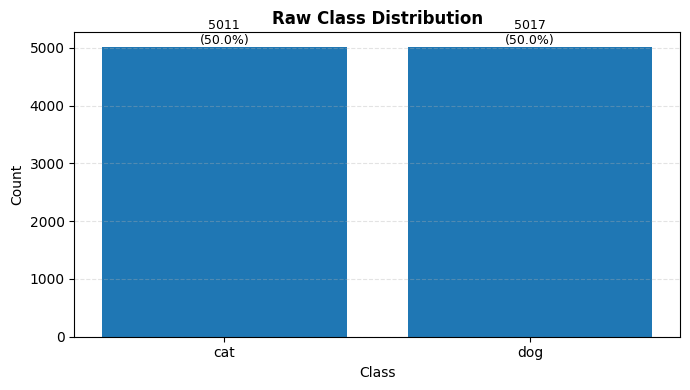

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Raw Class Distribution'}, xlabel='Class', ylabel='Count'>)

In [ ]:
dataset_root = resolve_dataset_root(
    dataset_id=config["dataset"].get("dataset_id"),
    local_root=config["dataset"].get("local_root"),
    kaggle_input_dir=config["dataset"]["kaggle_input_dir"],
    extensions=config["dataset"]["extensions"],
    allow_download=True,
)

raw_df = build_raw_dataframe(
    root=dataset_root,
    extensions=config["dataset"]["extensions"],
    class_map=config["dataset"]["class_map"],
    drop_unknown=config["dataset"]["drop_unknown"],
)

raw_summary_df = summarize_class_distribution(raw_df, label_col="label_name")

save_dataframe(raw_df, reports_dir / "raw_image_index.csv")
save_dataframe(raw_summary_df, reports_dir / "raw_class_distribution.csv")

print("Dataset root:", dataset_root)
print("Raw dataframe shape:", raw_df.shape)

display(raw_summary_df)

plot_class_distribution_bar(
    raw_df,
    label_col="label_name",
    title="Raw Class Distribution",
    save_path=figures_dir / "raw_class_distribution.png",
    show=True,
)

## 6. Audit image quality

The audit step computes reusable quality metrics and perceptual hashes.

The output is cached as `audit_dataframe.csv`.

In [ ]:
audit_path = reports_dir / "audit_dataframe.csv"

if audit_path.exists():
    audit_df = pd.read_csv(audit_path)
else:
    audit_df = audit_dataframe(
        raw_df,
        path_col=config["audit"]["path_col"],
        label_col=config["audit"]["label_col"],
        label_name_col=config["audit"]["label_name_col"],
        compute_hash=config["audit"]["compute_hash"],
        preserve_cols=["sample_id"] if "sample_id" in raw_df.columns else None,
        show_progress=True,
    )
    save_dataframe(audit_df, audit_path)

audit_stats_df = describe_audit_metrics(audit_df)
save_dataframe(audit_stats_df, reports_dir / "audit_metric_summary.csv")

print("Audit dataframe shape:", audit_df.shape)
display(audit_stats_df.head(20))

Auditing images:   0%|          | 0/10028 [00:00<?, ?it/s]

Audit dataframe shape: (10028, 31)


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
blur_laplacian,10028.0,971.337776,1792.087478,6.749261e+00,26.035995,59.547394,93.814255,187.786918,418.211700,987.357434,2236.669172,3706.367605,8959.514138,42627.022600
entropy,10028.0,7.369314,0.400106,1.621980e+00,6.091403,6.707126,6.920718,7.205523,7.447343,7.629322,7.750570,7.802087,7.879005,7.982241
brightness_mean,10028.0,117.371450,27.411632,2.318366e+01,54.696665,72.423072,82.793506,99.317449,117.149483,134.502445,151.481151,162.821512,187.235858,238.124254
brightness_std,10028.0,56.752996,13.507871,1.567177e+01,26.999541,34.794312,39.564142,47.510186,56.341058,65.662144,74.258418,79.959776,89.465830,113.555591
gray_diff_mean,10028.0,29.663283,17.442504,0.000000e+00,5.675096,9.393019,11.893789,17.309167,25.733459,38.000361,52.649345,62.995219,86.885270,193.906845
gray_diff_p95,10028.0,69.403401,35.912405,0.000000e+00,15.000000,24.000000,29.000000,44.000000,63.000000,87.000000,116.000000,137.000000,188.000000,253.000000
near_gray_ratio_10,10028.0,0.299068,0.215406,0.000000e+00,0.001372,0.018559,0.044459,0.122849,0.260523,0.442879,0.608311,0.716136,0.866287,1.000000
dark_ratio,10028.0,0.034029,0.063635,0.000000e+00,0.000000,0.000000,0.000000,0.000413,0.007386,0.038063,0.102495,0.162071,0.312467,0.819071
bright_ratio,10028.0,0.033150,0.069405,0.000000e+00,0.000000,0.000000,0.000000,0.000180,0.006290,0.034102,0.094687,0.159454,0.338857,0.905371
near_mono_ratio,10028.0,0.067179,0.090793,0.000000e+00,0.000000,0.000203,0.001050,0.008053,0.034163,0.090134,0.177429,0.245745,0.426192,0.952878


## 7. Apply Sweet Spot cleaning

The final Sweet Spot config keeps valid images and avoids aggressive quality filtering.

In the completed run:

```text
Raw: 10028
Clean: 10028
Removed: 0
```

In [ ]:
clean_df, removed_df = apply_cleaning(audit_df, config["cleaning"])

cleaning_summary_df = summarize_cleaning(
    raw_df=audit_df,
    clean_df=clean_df,
    removed_df=removed_df,
    label_col="label_name",
)

removal_reasons_df = summarize_removal_reasons(
    removed_df,
    reason_col="removal_reasons" if "removal_reasons" in removed_df.columns else "removal_reason",
)

retention_report = evaluate_cleaning_retention(
    raw_df=audit_df,
    clean_df=clean_df,
    label_col="label",
)

save_dataframe(clean_df, reports_dir / "clean_dataframe.csv")
save_dataframe(removed_df, reports_dir / "removed_dataframe.csv")
save_dataframe(cleaning_summary_df, reports_dir / "cleaning_summary.csv")
save_dataframe(removal_reasons_df, reports_dir / "removal_reasons_summary.csv")
save_json(retention_report, reports_dir / "cleaning_retention_report.json")

print("Clean dataframe shape:", clean_df.shape)
print("Removed dataframe shape:", removed_df.shape)

display(cleaning_summary_df)
display(removal_reasons_df)
display(pd.DataFrame([retention_report]))

if not removed_df.empty:
    plot_image_grid_from_df(
        removed_df,
        n=12,
        path_col="path",
        title_col="label_name" if "label_name" in removed_df.columns else None,
        subtitle_cols=[
            col for col in ["removal_reason", "removal_reasons", "blur_laplacian", "min_side", "entropy"]
            if col in removed_df.columns
        ],
        random_sample=True,
        seed=config["seed"],
        suptitle="Removed Image Examples",
        save_path=figures_dir / "removed_image_examples.png",
        show=True,
    )
else:
    print("No images were removed by the selected Sweet Spot cleaning config.")

Clean dataframe shape: (10028, 53)
Removed dataframe shape: (0, 53)


,label_name,count_before,count_after,count_removed,pct_before,pct_after,removal_rate_pct
0,cat,5011,5011,0,49.97,49.97,0.0
1,dog,5017,5017,0,50.03,50.03,0.0
2,TOTAL,10028,10028,0,100.00,100.00,0.0


,removal_reason,count,percentage


,n_before,n_after,n_removed,retention_rate,removal_rate,retention_pct,removal_pct,class_balance_shift,class_balance_shift_pct
0,10028,10028,0,1.0,0.0,100.0,0.0,0.0,0.0


No images were removed by the selected Sweet Spot cleaning config.


## 8. Train/validation/test split

The validation set selects the best grid-search configuration.  
The test set is used only once for final evaluation.

Train: (8022, 54)
Validation: (1003, 54)
Test: (1003, 54)


,split,split_size,label_name,count,percentage
0,train,8022,cat,4009,49.98
1,train,8022,dog,4013,50.02
2,val,1003,cat,501,49.95
3,val,1003,dog,502,50.05
4,test,1003,cat,501,49.95
5,test,1003,dog,502,50.05


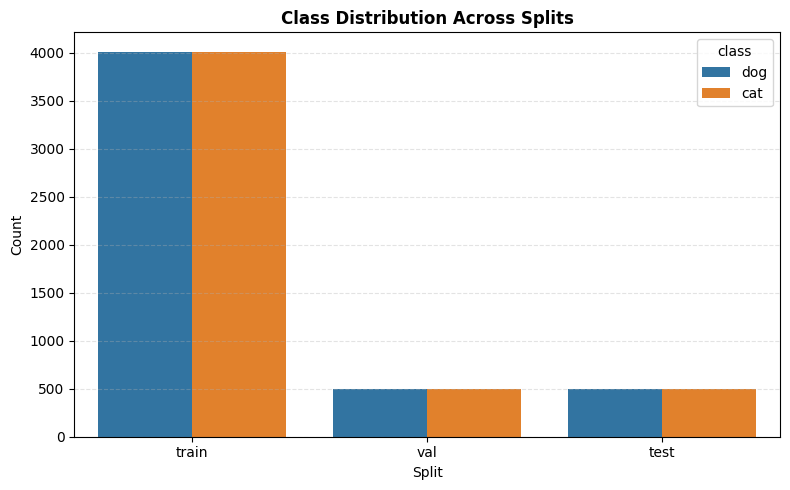

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Class Distribution Across Splits'}, xlabel='Split', ylabel='Count'>)

In [ ]:
train_df, val_df, test_df = stratified_split(
    clean_df,
    train_ratio=config["split"]["train_ratio"],
    val_ratio=config["split"]["val_ratio"],
    test_ratio=config["split"]["test_ratio"],
    seed=config["seed"],
    label_col=config["split"]["label_col"],
)

split_summary_df = summarize_split_distribution(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_col="label_name",
)

save_dataframe(train_df, reports_dir / "train_dataframe.csv")
save_dataframe(val_df, reports_dir / "val_dataframe.csv")
save_dataframe(test_df, reports_dir / "test_dataframe.csv")
save_dataframe(split_summary_df, reports_dir / "split_distribution.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

display(split_summary_df)

plot_split_distribution(
    splits={"train": train_df, "val": val_df, "test": test_df},
    label_col="label_name",
    save_path=figures_dir / "split_distribution.png",
    show=True,
)

## 9. One-experiment runner

Each experiment:

```text
build transform
→ extract/load features
→ train classifier
→ evaluate on validation set
```

Feature extraction is cached by preprocessing and backbone, so multiple classifiers can reuse the same feature matrices.

In [ ]:
def run_exhaustive_experiment(index: int, experiment: dict) -> dict:
    run_name = experiment_run_name(experiment, index)
    experiment_config = merge_overrides(config, experiment)

    pre_cfg = experiment_config["preprocessing"]
    feat_cfg = experiment_config["feature_extraction"]
    clf_cfg = experiment_config["classifier"]

    train_transform, eval_transform = build_feature_transforms(pre_cfg)
    feature_dir = features_dir / feature_cache_key(experiment_config)

    start_time = time.perf_counter()

    feature_result = extract_feature_splits(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        train_transform=train_transform,
        eval_transform=eval_transform,
        backbone_name=feat_cfg["backbone"],
        batch_size=feat_cfg.get("batch_size", 128),
        device=device,
        num_workers=feat_cfg.get("num_workers", 2),
        output_dir=feature_dir,
        pretrained=feat_cfg.get("pretrained", True),
        data_parallel=feat_cfg.get("data_parallel", False),
        force_recompute=feat_cfg.get("force_recompute", False),
        path_col="path",
        label_col="label",
        show_progress=True,
        on_error=feat_cfg.get("on_error", "raise"),
    )

    model = train_classifier(
        feature_result["X_train"],
        feature_result["y_train"],
        classifier_name=clf_cfg["name"],
        seed=experiment_config.get("seed", 42),
        **dict(clf_cfg.get("params", {})),
    )

    val_metrics = evaluate_estimator(
        model,
        feature_result["X_val"],
        feature_result["y_val"],
        model_name=run_name,
    )

    elapsed = time.perf_counter() - start_time

    record = {
        "run_name": run_name,
        "status": "ok",
        "experiment_type": experiment.get("experiment_type", "base"),
        "classifier_label": experiment.get("classifier_label", clf_cfg["name"]),
        "preprocessing.mode": pre_cfg["mode"],
        "preprocessing.image_size": pre_cfg["image_size"],
        "feature_extraction.backbone": feat_cfg["backbone"],
        "classifier.name": clf_cfg["name"],
        "classifier.params": json.dumps(clf_cfg.get("params", {}), default=str),
        "loaded_from_cache": bool(feature_result.get("loaded_from_cache", False)),
        "fit_time_seconds": round(float(elapsed), 6),
        "feature_dir": str(feature_dir),
        **val_metrics,
    }

    return {
        "record": record,
        "model": model,
        "feature_result": feature_result,
        "config": experiment_config,
    }

## 10. Run exhaustive grid search

The notebook saves intermediate results after every experiment.  
If Colab disconnects, rerunning can reuse cached feature files.

In [ ]:
results_path = reports_dir / "exhaustive_grid_132_results.csv"
intermediate_path = reports_dir / "exhaustive_grid_132_results_intermediate.csv"

records = []
failures = []
last_result = None

for index, experiment in enumerate(experiments):
    run_name = experiment_run_name(experiment, index)
    print(f"\n[{index + 1}/{len(experiments)}] {run_name}")

    try:
        last_result = run_exhaustive_experiment(index, experiment)
        records.append(last_result["record"])

    except Exception as exc:
        failure_record = {
            "run_name": run_name,
            "status": "failed",
            "error": repr(exc),
            **{k: v for k, v in experiment.items() if k != "classifier.params"},
            "classifier.params": json.dumps(experiment.get("classifier.params", {}), default=str),
        }
        records.append(failure_record)
        failures.append(failure_record)

        pd.DataFrame(records).to_csv(intermediate_path, index=False)

        if config["exhaustive_grid"].get("fail_fast", True):
            raise

    pd.DataFrame(records).to_csv(intermediate_path, index=False)
    clear_memory()

exhaustive_results_df = pd.DataFrame(records)
save_dataframe(exhaustive_results_df, results_path)

print("Finished experiments:", len(exhaustive_results_df))
print("Failures:", len(failures))

display(exhaustive_results_df.head())
display(exhaustive_results_df.tail())


[1/132] 000__mode-stretch__size-224__backbone-efficientnet_b0__clf-lr_c0.1
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 153MB/s]


Extracting features (efficientnet_b0):   0%|          | 0/63 [00:00<?, ?it/s]

Extracting features (efficientnet_b0):   0%|          | 0/8 [00:00<?, ?it/s]

Extracting features (efficientnet_b0):   0%|          | 0/8 [00:00<?, ?it/s]

...

Extracting features (vgg16):   0%|          | 0/8 [00:00<?, ?it/s]

Extracting features (vgg16):   0%|          | 0/8 [00:00<?, ?it/s]


[123/132] 122__mode-augmented__size-224__backbone-vgg16__clf-lr_c1.0

[124/132] 123__mode-augmented__size-224__backbone-vgg16__clf-lr_c10.0

[125/132] 124__mode-augmented__size-224__backbone-vgg16__clf-svmlinear_c0.1

[126/132] 125__mode-augmented__size-224__backbone-vgg16__clf-svmlinear_c1.0

[127/132] 126__mode-augmented__size-224__backbone-vgg16__clf-rf_n100_depthnone

[128/132] 127__mode-augmented__size-224__backbone-vgg16__clf-rf_n100_depth20

[129/132] 128__mode-augmented__size-224__backbone-vgg16__clf-rf_n200_depthnone

[130/132] 129__mode-augmented__size-224__backbone-vgg16__clf-rf_n200_depth20

[131/132] 130__mode-augmented__size-224__backbone-vgg16__clf-votingsoft_default

[132/132] 131__mode-augmented__size-224__backbone-vgg16__clf-stacking_default
Finished experiments: 132
Failures: 0


,run_name,status,experiment_type,classifier_label,preprocessing.mode,preprocessing.image_size,feature_extraction.backbone,classifier.name,classifier.params,loaded_from_cache,...,feature_dir,model,accuracy,precision_macro,recall_macro,f1_macro,wrong_predictions,total_samples,error_rate,roc_auc
0,000__mode-stretch__size-224__backbone-efficien...,ok,base,LR_C0.1,stretch,224,efficientnet_b0,logistic_regression,"{""C"": 0.1, ""max_iter"": 3000, ""class_weight"": n...",False,...,/content/cat-dog-image-classifier/features/gri...,000__mode-stretch__size-224__backbone-efficien...,0.994018,0.994024,0.994020,0.994018,6,1003,0.005982,0.999952
1,001__mode-stretch__size-224__backbone-efficien...,ok,base,LR_C1.0,stretch,224,efficientnet_b0,logistic_regression,"{""C"": 1.0, ""max_iter"": 3000, ""class_weight"": n...",True,...,/content/cat-dog-image-classifier/features/gri...,001__mode-stretch__size-224__backbone-efficien...,0.994018,0.994045,0.994022,0.994018,6,1003,0.005982,0.999928
2,002__mode-stretch__size-224__backbone-efficien...,ok,base,LR_C10.0,stretch,224,efficientnet_b0,logistic_regression,"{""C"": 10.0, ""max_iter"": 3000, ""class_weight"": ...",True,...,/content/cat-dog-image-classifier/features/gri...,002__mode-stretch__size-224__backbone-efficien...,0.994018,0.994045,0.994022,0.994018,6,1003,0.005982,0.999928
3,003__mode-stretch__size-224__backbone-efficien...,ok,base,SVMLinear_C0.1,stretch,224,efficientnet_b0,svm_linear,"{""C"": 0.1, ""probability"": true, ""class_weight""...",True,...,/content/cat-dog-image-classifier/features/gri...,003__mode-stretch__size-224__backbone-efficien...,0.992024,0.992051,0.992028,0.992024,8,1003,0.007976,0.999837
4,004__mode-stretch__size-224__backbone-efficien...,ok,base,SVMLinear_C1.0,stretch,224,efficientnet_b0,svm_linear,"{""C"": 1.0, ""probability"": true, ""class_weight""...",True,...,/content/cat-dog-image-classifier/features/gri...,004__mode-stretch__size-224__backbone-efficien...,0.992024,0.992051,0.992028,0.992024,8,1003,0.007976,0.999837


,run_name,status,experiment_type,classifier_label,preprocessing.mode,preprocessing.image_size,feature_extraction.backbone,classifier.name,classifier.params,loaded_from_cache,...,feature_dir,model,accuracy,precision_macro,recall_macro,f1_macro,wrong_predictions,total_samples,error_rate,roc_auc
127,127__mode-augmented__size-224__backbone-vgg16_...,ok,base,RF_n100_depth20,augmented,224,vgg16,random_forest,"{""n_estimators"": 100, ""max_depth"": 20, ""n_jobs...",True,...,/content/cat-dog-image-classifier/features/gri...,127__mode-augmented__size-224__backbone-vgg16_...,0.990030,0.990030,0.990030,0.990030,10,1003,0.009970,0.999730
128,128__mode-augmented__size-224__backbone-vgg16_...,ok,base,RF_n200_depthNone,augmented,224,vgg16,random_forest,"{""n_estimators"": 200, ""max_depth"": null, ""n_jo...",True,...,/content/cat-dog-image-classifier/features/gri...,128__mode-augmented__size-224__backbone-vgg16_...,0.989033,0.989034,0.989034,0.989033,11,1003,0.010967,0.999748
129,129__mode-augmented__size-224__backbone-vgg16_...,ok,base,RF_n200_depth20,augmented,224,vgg16,random_forest,"{""n_estimators"": 200, ""max_depth"": 20, ""n_jobs...",True,...,/content/cat-dog-image-classifier/features/gri...,129__mode-augmented__size-224__backbone-vgg16_...,0.990030,0.990036,0.990032,0.990030,10,1003,0.009970,0.999761
130,130__mode-augmented__size-224__backbone-vgg16_...,ok,ensemble,VotingSoft_default,augmented,224,vgg16,voting_soft,"{""voting"": ""soft"", ""n_jobs"": -1, ""lr"": {""C"": 0...",True,...,/content/cat-dog-image-classifier/features/gri...,130__mode-augmented__size-224__backbone-vgg16_...,0.988036,0.988100,0.988042,0.988036,12,1003,0.011964,0.999543
131,131__mode-augmented__size-224__backbone-vgg16_...,ok,ensemble,Stacking_default,augmented,224,vgg16,stacking,"{""n_jobs"": -1, ""lr"": {""C"": 0.1, ""max_iter"": 30...",True,...,/content/cat-dog-image-classifier/features/gri...,131__mode-augmented__size-224__backbone-vgg16_...,0.991027,0.991042,0.991030,0.991027,9,1003,0.008973,0.999746


## 11. Rank validation results

The best configuration is selected by validation macro F1.

Completed run best row:

```text
augmented + EfficientNet-B0 + Voting Soft
Validation macro F1 = 0.997009
Validation wrong predictions = 3 / 1003
```

In [ ]:
ranked_results_df = sort_ranked_results(
    exhaustive_results_df,
    primary_metric=config["exhaustive_grid"]["primary_metric"],
    tie_breakers=config["exhaustive_grid"].get("tie_breakers", ["accuracy"]),
)

save_dataframe(ranked_results_df, reports_dir / "exhaustive_grid_132_results_ranked.csv")

display(ranked_results_df.head(20))

,run_name,status,experiment_type,classifier_label,preprocessing.mode,preprocessing.image_size,feature_extraction.backbone,classifier.name,classifier.params,loaded_from_cache,...,feature_dir,model,accuracy,precision_macro,recall_macro,f1_macro,wrong_predictions,total_samples,error_rate,roc_auc
0,108__mode-augmented__size-224__backbone-effici...,ok,ensemble,VotingSoft_default,augmented,224,efficientnet_b0,voting_soft,"{""voting"": ""soft"", ""n_jobs"": -1, ""lr"": {""C"": 0...",True,...,/content/cat-dog-image-classifier/features/gri...,108__mode-augmented__size-224__backbone-effici...,0.997009,0.997024,0.997012,0.997009,3,1003,0.002991,0.999948
1,099__mode-augmented__size-224__backbone-effici...,ok,base,LR_C0.1,augmented,224,efficientnet_b0,logistic_regression,"{""C"": 0.1, ""max_iter"": 3000, ""class_weight"": n...",False,...,/content/cat-dog-image-classifier/features/gri...,099__mode-augmented__size-224__backbone-effici...,0.997009,0.997024,0.997012,0.997009,3,1003,0.002991,0.999972
2,109__mode-augmented__size-224__backbone-effici...,ok,ensemble,Stacking_default,augmented,224,efficientnet_b0,stacking,"{""n_jobs"": -1, ""lr"": {""C"": 0.1, ""max_iter"": 30...",True,...,/content/cat-dog-image-classifier/features/gri...,109__mode-augmented__size-224__backbone-effici...,0.997009,0.997024,0.997012,0.997009,3,1003,0.002991,0.999924
3,076__mode-letterbox__size-224__backbone-effici...,ok,ensemble,Stacking_default,letterbox,224,efficientnet_b0,stacking,"{""n_jobs"": -1, ""lr"": {""C"": 0.1, ""max_iter"": 30...",True,...,/content/cat-dog-image-classifier/features/gri...,076__mode-letterbox__size-224__backbone-effici...,0.996012,0.996018,0.996014,0.996012,4,1003,0.003988,0.999964
4,010__mode-stretch__size-224__backbone-efficien...,ok,ensemble,Stacking_default,stretch,224,efficientnet_b0,stacking,"{""n_jobs"": -1, ""lr"": {""C"": 0.1, ""max_iter"": 30...",True,...,/content/cat-dog-image-classifier/features/gri...,010__mode-stretch__size-224__backbone-efficien...,0.995015,0.995016,0.995016,0.995015,5,1003,0.004985,0.999869
5,034__mode-center_crop__size-224__backbone-effi...,ok,base,LR_C1.0,center_crop,224,efficientnet_b0,logistic_regression,"{""C"": 1.0, ""max_iter"": 3000, ""class_weight"": n...",True,...,/content/cat-dog-image-classifier/features/gri...,034__mode-center_crop__size-224__backbone-effi...,0.995015,0.995018,0.995014,0.995015,5,1003,0.004985,0.999857
6,075__mode-letterbox__size-224__backbone-effici...,ok,ensemble,VotingSoft_default,letterbox,224,efficientnet_b0,voting_soft,"{""voting"": ""soft"", ""n_jobs"": -1, ""lr"": {""C"": 0...",True,...,/content/cat-dog-image-classifier/features/gri...,075__mode-letterbox__size-224__backbone-effici...,0.995015,0.995030,0.995018,0.995015,5,1003,0.004985,0.999948
7,066__mode-letterbox__size-224__backbone-effici...,ok,base,LR_C0.1,letterbox,224,efficientnet_b0,logistic_regression,"{""C"": 0.1, ""max_iter"": 3000, ""class_weight"": n...",False,...,/content/cat-dog-image-classifier/features/gri...,066__mode-letterbox__size-224__backbone-effici...,0.995015,0.995030,0.995018,0.995015,5,1003,0.004985,0.999956
8,100__mode-augmented__size-224__backbone-effici...,ok,base,LR_C1.0,augmented,224,efficientnet_b0,logistic_regression,"{""C"": 1.0, ""max_iter"": 3000, ""class_weight"": n...",True,...,/content/cat-dog-image-classifier/features/gri...,100__mode-augmented__size-224__backbone-effici...,0.995015,0.995059,0.995020,0.995015,5,1003,0.004985,0.999960
9,036__mode-center_crop__size-224__backbone-effi...,ok,base,SVMLinear_C0.1,center_crop,224,efficientnet_b0,svm_linear,"{""C"": 0.1, ""probability"": true, ""class_weight""...",True,...,/content/cat-dog-image-classifier/features/gri...,036__mode-center_crop__size-224__backbone-effi...,0.995015,0.995036,0.995012,0.995015,5,1003,0.004985,0.999789


## 12. Visualize grid-search results

These charts compare preprocessing, backbone, and classifier effects.

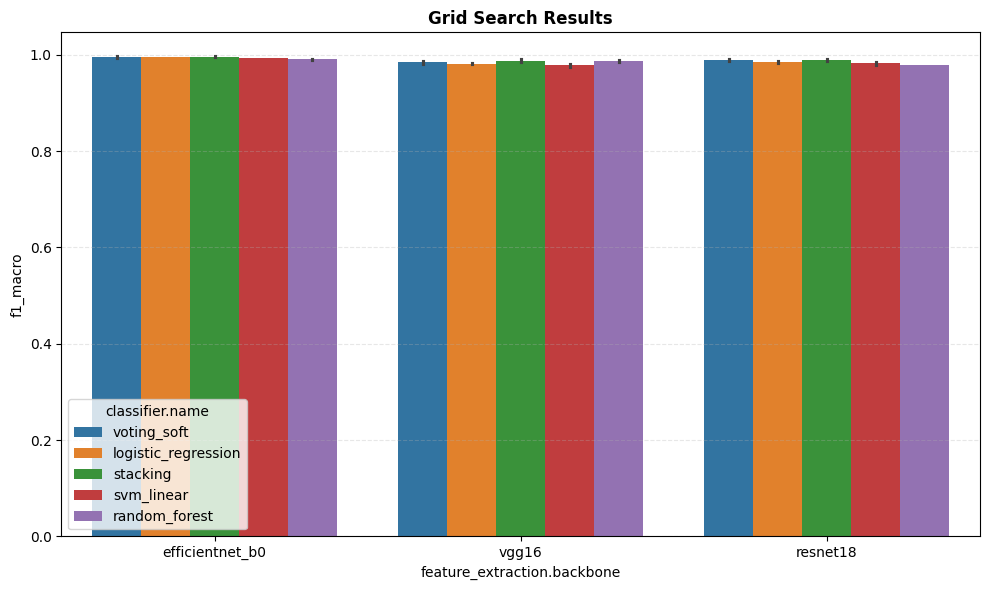

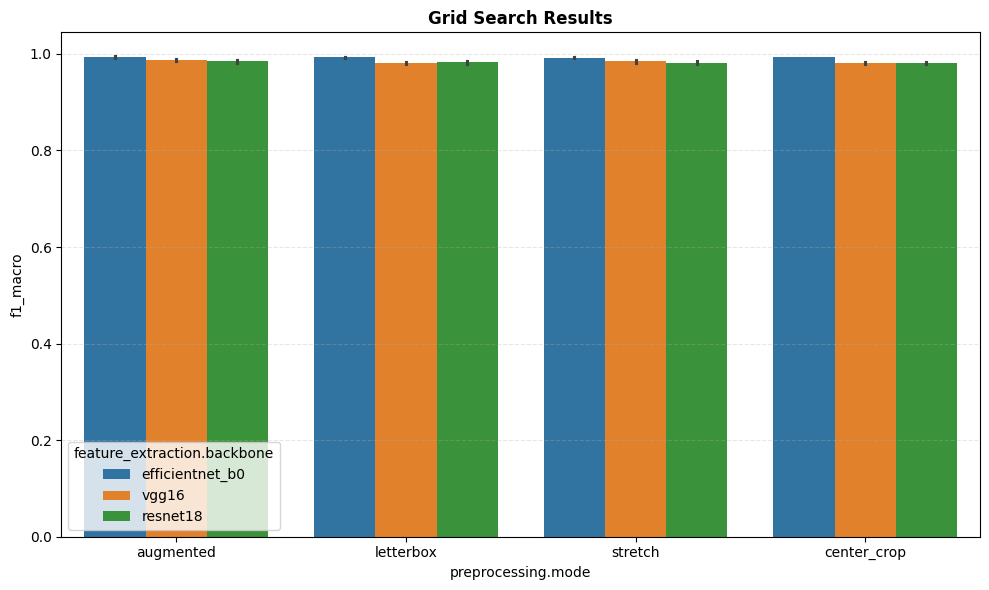

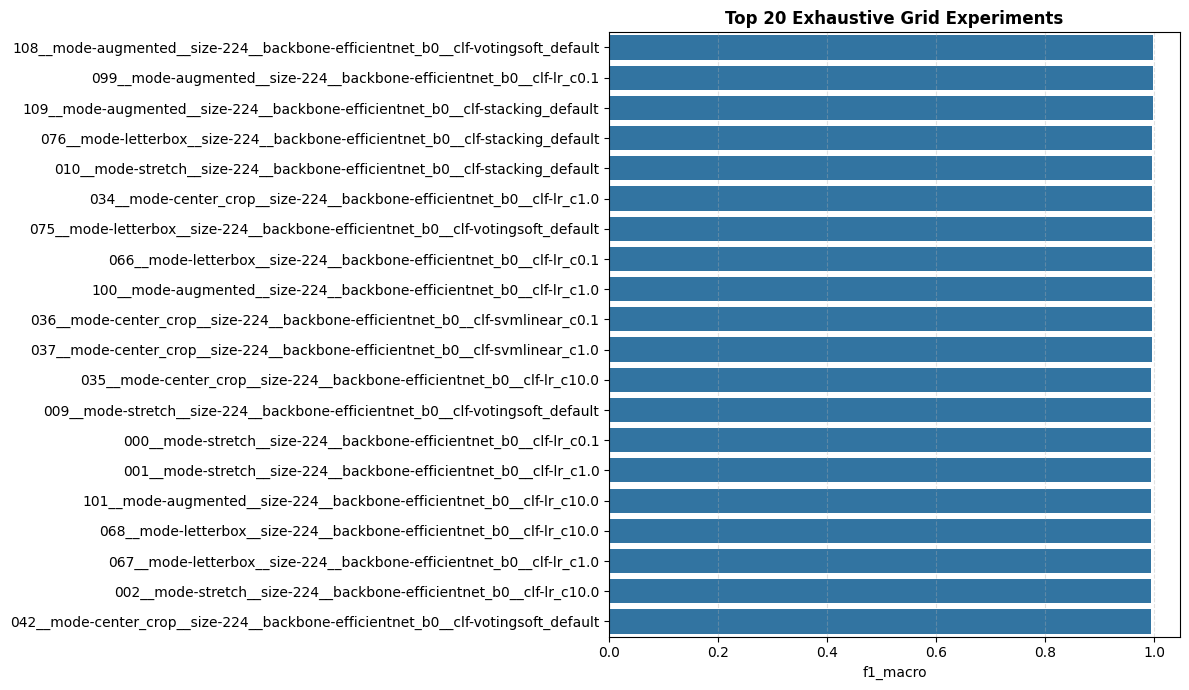

In [ ]:
plot_grid_search_results(
    ranked_results_df,
    x="feature_extraction.backbone",
    y=config["exhaustive_grid"]["primary_metric"],
    hue="classifier.name",
    save_path=figures_dir / "grid_by_backbone_classifier.png",
    show=True,
)

plot_grid_search_results(
    ranked_results_df,
    x="preprocessing.mode",
    y=config["exhaustive_grid"]["primary_metric"],
    hue="feature_extraction.backbone",
    save_path=figures_dir / "grid_by_preprocessing_backbone.png",
    show=True,
)

top20_df = ranked_results_df.head(20).copy()
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=top20_df, y="run_name", x=config["exhaustive_grid"]["primary_metric"], ax=ax)
ax.set_title("Top 20 Exhaustive Grid Experiments", fontweight="bold")
ax.set_xlabel(config["exhaustive_grid"]["primary_metric"])
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.35)
fig.tight_layout()
fig.savefig(figures_dir / "top20_exhaustive_grid.png", dpi=160, bbox_inches="tight")
plt.show()

## 13. Component-level summary and interpretation

From the completed run:

- `augmented` achieved the best maximum validation F1.
- `efficientnet_b0` clearly dominated the backbone comparison.
- `VotingSoft_default`, `Stacking_default`, and `LR_C0.1` reached the same top validation F1, but Voting Soft was selected as the best ranked row.

In [ ]:
component_summary = {
    "preprocessing": (
        ranked_results_df
        .groupby("preprocessing.mode")[config["exhaustive_grid"]["primary_metric"]]
        .agg(["count", "mean", "max"])
        .sort_values("max", ascending=False)
        .reset_index()
    ),
    "backbone": (
        ranked_results_df
        .groupby("feature_extraction.backbone")[config["exhaustive_grid"]["primary_metric"]]
        .agg(["count", "mean", "max"])
        .sort_values("max", ascending=False)
        .reset_index()
    ),
    "classifier": (
        ranked_results_df
        .groupby("classifier_label")[config["exhaustive_grid"]["primary_metric"]]
        .agg(["count", "mean", "max"])
        .sort_values("max", ascending=False)
        .reset_index()
    ),
    "classifier_type": (
        ranked_results_df
        .groupby("classifier.name")[config["exhaustive_grid"]["primary_metric"]]
        .agg(["count", "mean", "max"])
        .sort_values("max", ascending=False)
        .reset_index()
    ),
}

save_dataframe(component_summary["preprocessing"], reports_dir / "component_summary_preprocessing.csv")
save_dataframe(component_summary["backbone"], reports_dir / "component_summary_backbone.csv")
save_dataframe(component_summary["classifier"], reports_dir / "component_summary_classifier.csv")
save_dataframe(component_summary["classifier_type"], reports_dir / "component_summary_classifier_type.csv")

display(component_summary["preprocessing"])
display(component_summary["backbone"])
display(component_summary["classifier"])
display(component_summary["classifier_type"])

,preprocessing.mode,count,mean,max
0,augmented,33,0.988549,0.997009
1,letterbox,33,0.985436,0.996012
2,stretch,33,0.986192,0.995015
3,center_crop,33,0.985256,0.995015


,feature_extraction.backbone,count,mean,max
0,efficientnet_b0,44,0.992976,0.997009
1,resnet18,44,0.982663,0.992024
2,vgg16,44,0.983435,0.992024


,classifier_label,count,mean,max
0,LR_C0.1,12,0.988451,0.997009
1,VotingSoft_default,12,0.989116,0.997009
2,Stacking_default,12,0.990861,0.997009
3,LR_C1.0,12,0.986789,0.995015
4,SVMLinear_C0.1,12,0.984462,0.995015
5,SVMLinear_C1.0,12,0.983715,0.995015
6,LR_C10.0,12,0.985460,0.994018
7,RF_n100_depthNone,12,0.985043,0.994018
8,RF_n200_depth20,12,0.985624,0.992024
9,RF_n200_depthNone,12,0.985541,0.992024


,classifier.name,count,mean,max
0,logistic_regression,36,0.986900,0.997009
1,stacking,12,0.990861,0.997009
2,voting_soft,12,0.989116,0.997009
3,svm_linear,24,0.984089,0.995015
4,random_forest,48,0.985271,0.994018


## 14. Reconstruct and export the best validation config

In [ ]:
best_row = ranked_results_df.iloc[0].to_dict()

best_experiment = None
best_index = None

for index, experiment in enumerate(experiments):
    if experiment_run_name(experiment, index) == best_row["run_name"]:
        best_experiment = experiment
        best_index = index
        break

if best_experiment is None:
    raise ValueError("Could not reconstruct best experiment from ranked results.")

best_grid_config = merge_overrides(config, best_experiment)

save_json(best_grid_config, reports_dir / "best_exhaustive_132_config.json")

print("Best validation row:")
print(json.dumps(best_row, indent=2, default=str))

print("\nBest config core:")
print(json.dumps({
    "cleaning": best_grid_config["cleaning"],
    "preprocessing": best_grid_config["preprocessing"],
    "feature_extraction": best_grid_config["feature_extraction"],
    "classifier": best_grid_config["classifier"],
}, indent=2, default=str))

Best validation row:
{
  "run_name": "108__mode-augmented__size-224__backbone-efficientnet_b0__clf-votingsoft_default",
  "status": "ok",
  "experiment_type": "ensemble",
  "classifier_label": "VotingSoft_default",
  "preprocessing.mode": "augmented",
  "preprocessing.image_size": 224,
  "feature_extraction.backbone": "efficientnet_b0",
  "classifier.name": "voting_soft",
  "classifier.params": "{\"voting\": \"soft\", \"n_jobs\": -1, \"lr\": {\"C\": 0.1, \"max_iter\": 3000, \"n_jobs\": -1}, \"svm\": {\"C\": 0.1, \"probability\": true}, \"rf\": {\"n_estimators\": 100, \"n_jobs\": -1}}",
  "loaded_from_cache": true,
  "fit_time_seconds": 49.579353,
  "feature_dir": "/content/cat-dog-image-classifier/features/grid_search_exhaustive_132/mode-augmented__size-224__norm-imagenet__backbone-efficientnet_b0__pretrained-true",
  "model": "108__mode-augmented__size-224__backbone-efficientnet_b0__clf-votingsoft_default",
  "accuracy": 0.9970089730807578,
  "precision_macro": 0.9970238095238095,
  "

## 15. Final evaluation on held-out test set

The validation set selects the model.  
The test set estimates final generalization performance.

Completed run result:

```text
Test macro F1 = 0.993021
Wrong predictions = 7 / 1003
ROC-AUC = 0.999849
```

In [ ]:
best_result = run_exhaustive_experiment(best_index, best_experiment)
best_model = best_result["model"]
best_features = best_result["feature_result"]

test_metrics = evaluate_estimator(
    best_model,
    best_features["X_test"],
    best_features["y_test"],
    model_name="best_exhaustive_132_config",
)

final_metrics_df = pd.DataFrame([
    {
        "split": "validation",
        **{
            k: best_row.get(k)
            for k in [
                "accuracy",
                "precision_macro",
                "recall_macro",
                "f1_macro",
                "roc_auc",
                "wrong_predictions",
                "total_samples",
                "error_rate",
            ]
            if k in best_row
        },
    },
    {"split": "test", **test_metrics},
])

save_dataframe(final_metrics_df, reports_dir / "best_exhaustive_132_validation_test_metrics.csv")
save_pickle(best_model, models_dir / "best_exhaustive_132_model.pkl")

display(final_metrics_df)

,split,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,wrong_predictions,total_samples,error_rate,model
0,validation,0.997009,0.997024,0.997012,0.997009,0.999948,3,1003,0.002991,NaN
1,test,0.993021,0.993022,0.993022,0.993021,0.999849,7,1003,0.006979,best_exhaustive_132_config


## 16. Confusion matrix and wrong predictions

The wrong-prediction table supports qualitative analysis in the final report.

In [ ]:
test_pred = best_model.predict(best_features["X_test"])

test_prob = None
if hasattr(best_model, "predict_proba"):
    try:
        test_prob = best_model.predict_proba(best_features["X_test"])
    except Exception:
        test_prob = None

label_names = config["dataset"].get("label_names", {0: "cat", 1: "dog"})
label_map = {int(k): v for k, v in label_names.items()} if isinstance(label_names, dict) else {0: "cat", 1: "dog"}

evaluation_payload = evaluate_predictions(
    y_true=best_features["y_test"],
    y_pred=test_pred,
    y_prob=test_prob,
    labels=[0, 1],
    label_names=label_map,
)

test_report_df = evaluation_payload["report"]
test_cm_df = evaluation_payload["confusion_matrix"]
test_metric_dict = evaluation_payload["metrics"]

wrong_df = find_wrong_predictions(
    df=test_df,
    y_true=best_features["y_test"],
    y_pred=test_pred,
    y_prob=test_prob,
    path_col="path",
    label_map=label_map,
)

save_dataframe(test_report_df.reset_index().rename(columns={"index": "label"}), reports_dir / "best_exhaustive_132_test_classification_report.csv")
save_dataframe(test_cm_df, reports_dir / "best_exhaustive_132_test_confusion_matrix.csv")
save_dataframe(wrong_df, reports_dir / "best_exhaustive_132_test_wrong_predictions.csv")
save_json(test_metric_dict, reports_dir / "best_exhaustive_132_test_metrics.json")

display(pd.DataFrame([test_metric_dict]))
display(test_report_df)
display(test_cm_df)
display(wrong_df)

,accuracy,precision_macro,recall_macro,f1_macro,wrong_predictions,total_samples,error_rate,roc_auc
0,0.993021,0.993022,0.993022,0.993021,7,1003,0.006979,0.999849


,precision,recall,f1-score,support
cat,0.992032,0.994012,0.993021,501.000000
dog,0.994012,0.992032,0.993021,502.000000
accuracy,0.993021,0.993021,0.993021,0.993021
macro avg,0.993022,0.993022,0.993021,1003.000000
weighted avg,0.993023,0.993021,0.993021,1003.000000


,Predicted cat,Predicted dog
Actual cat,498,3
Actual dog,4,498


,path,true_label,pred_label,true_label_name,pred_label_name,confidence,is_correct
0,/kaggle/input/cat-and-dog/training_set/trainin...,0,1,cat,dog,0.523178,False
1,/kaggle/input/cat-and-dog/training_set/trainin...,1,0,dog,cat,0.878708,False
2,/kaggle/input/cat-and-dog/training_set/trainin...,0,1,cat,dog,0.686100,False
3,/kaggle/input/cat-and-dog/training_set/trainin...,1,0,dog,cat,0.737209,False
4,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,1,cat,dog,0.742401,False
5,/kaggle/input/cat-and-dog/test_set/test_set/do...,1,0,dog,cat,0.723722,False
6,/kaggle/input/cat-and-dog/test_set/test_set/do...,1,0,dog,cat,0.752834,False


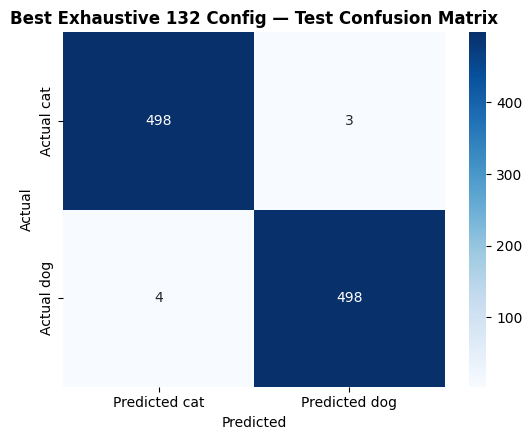

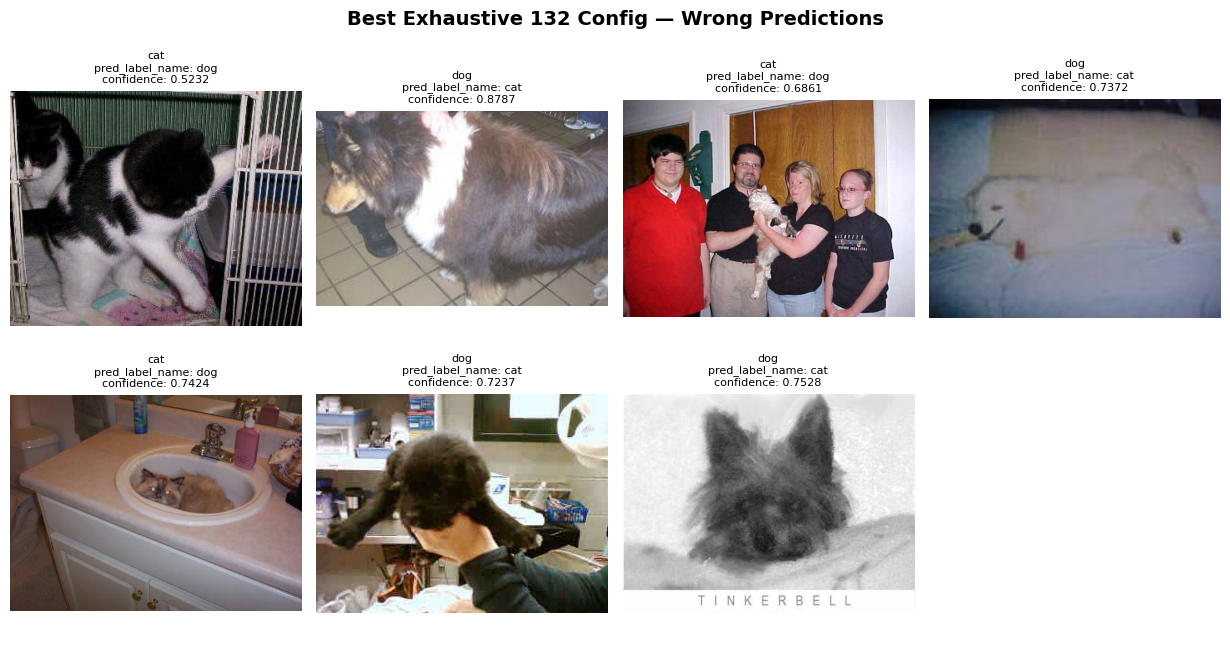

In [ ]:
plot_confusion_matrix(
    test_cm_df,
    title="Best Exhaustive 132 Config — Test Confusion Matrix",
    save_path=figures_dir / "best_exhaustive_132_test_confusion_matrix.png",
    show=True,
)

if not wrong_df.empty:
    plot_image_grid_from_df(
        wrong_df,
        n=12,
        path_col="path",
        title_col="true_label_name" if "true_label_name" in wrong_df.columns else None,
        subtitle_cols=[col for col in ["pred_label_name", "confidence"] if col in wrong_df.columns],
        suptitle="Best Exhaustive 132 Config — Wrong Predictions",
        save_path=figures_dir / "best_exhaustive_132_test_wrong_predictions.png",
        show=True,
    )
else:
    print("No wrong predictions on the test set.")

## 17. Export final report

The final report JSON contains dataset sizes, search axes, best validation row, selected config, and test metrics.

In [ ]:
final_grid_report = {
    "platform": "colab",
    "gpu_count": int(torch.cuda.device_count()),
    "gpu_names": [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())] if torch.cuda.is_available() else [],
    "n_raw": int(len(raw_df)),
    "n_clean": int(len(clean_df)),
    "n_removed": int(len(removed_df)),
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "test_size": int(len(test_df)),
    "n_experiments": int(len(experiments)),
    "n_successful_experiments": int((exhaustive_results_df["status"] == "ok").sum()) if "status" in exhaustive_results_df.columns else int(len(exhaustive_results_df)),
    "n_failed_experiments": int((exhaustive_results_df["status"] == "failed").sum()) if "status" in exhaustive_results_df.columns else 0,
    "search_axes": {
        "preprocessing_modes": config["exhaustive_grid"]["preprocessing_modes"],
        "image_sizes": config["exhaustive_grid"]["image_sizes"],
        "backbones": config["exhaustive_grid"]["backbones"],
        "classifier_grid": build_classifier_grid(),
    },
    "best_validation_row": best_row,
    "best_config_core": {
        "cleaning": best_grid_config["cleaning"],
        "preprocessing": best_grid_config["preprocessing"],
        "feature_extraction": best_grid_config["feature_extraction"],
        "classifier": best_grid_config["classifier"],
    },
    "test_metrics": test_metric_dict,
    "wrong_predictions": int(len(wrong_df)),
    "outputs": {
        "reports_dir": str(reports_dir),
        "figures_dir": str(figures_dir),
        "features_dir": str(features_dir),
        "models_dir": str(models_dir),
    },
}

save_json(final_grid_report, reports_dir / "exhaustive_grid_132_final_report.json")

print(json.dumps(final_grid_report, indent=2, default=str))

{
  "platform": "colab",
  "gpu_count": 1,
  "gpu_names": [
    "Tesla T4"
  ],
  "n_raw": 10028,
  "n_clean": 10028,
  "n_removed": 0,
  "train_size": 8022,
  "val_size": 1003,
  "test_size": 1003,
  "n_experiments": 132,
  "n_successful_experiments": 132,
  "n_failed_experiments": 0,
  "search_axes": {
    "preprocessing_modes": [
      "stretch",
      "center_crop",
      "letterbox",
      "augmented"
    ],
    "image_sizes": [
      224
    ],
    "backbones": [
      "efficientnet_b0",
      "resnet18",
      "vgg16"
    ],
    "classifier_grid": [
      {
        "classifier_label": "LR_C0.1",
        "classifier.name": "logistic_regression",
        "classifier.params": {
          "C": 0.1,
          "max_iter": 3000,
          "class_weight": null,
          "n_jobs": -1
        },
        "experiment_type": "base"
      },
      {
        "classifier_label": "LR_C1.0",
        "classifier.name": "logistic_regression",
        "classifier.params": {
          "C": 1.0,
    

# Final conclusion

The exhaustive grid search selected:

```text
Augmented 224
+ EfficientNet-B0 frozen feature extraction
+ Soft Voting classifier
```

as the best validation configuration.

The selected model achieved strong held-out test performance:

```text
Macro F1 ≈ 0.9930
Wrong predictions = 7 / 1003
```

## Final default config for the classical pipeline

```python
"cleaning": {
    "enabled": False,
    "remove_corrupted": True,
    "remove_duplicates": True,
    "duplicate_hamming_threshold": 4,
}

"preprocessing": {
    "mode": "augmented",
    "image_size": 224,
    "train_augmentation": False,
    "normalize": "imagenet",
}

"feature_extraction": {
    "backbone": "efficientnet_b0",
    "pretrained": True,
    "batch_size": 128,
    "num_workers": 2,
    "data_parallel": False,
    "force_recompute": False,
    "file_format": "npy",
    "on_error": "raise",
}

"classifier": {
    "name": "voting_soft",
    "params": {
        "voting": "soft",
        "n_jobs": -1,
        "lr": {
            "C": 0.1,
            "max_iter": 3000,
            "n_jobs": -1,
        },
        "svm": {
            "C": 0.1,
            "probability": True,
        },
        "rf": {
            "n_estimators": 100,
            "n_jobs": -1,
        },
    },
}
```